# Pretrained baselines without SAM — ResNet18, ViT‑B/16
- Fine‑tuning schedule, LLRD for ViT head, recall‑first evaluation.

In [1]:
# Clean imports + path setup
import sys
from pathlib import Path
import warnings

# tqdm: prefer notebook widgets, fallback to text
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists():
        break
    proj_root = proj_root.parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))
print("sys.path[0] =", sys.path[0])

# Weights path
weights_path = proj_root / "notebooks" / "weights" / "ViT-B_16.npz"
print("weights:", weights_path)

# Project imports
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project
weights: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project/notebooks/weights/ViT-B_16.npz


device(type='mps')

In [2]:
# --- Cell 2: data + training configs (pretrained, SAM OFF) ---

DATASET_DIR = Path("../Data/chest_xray")

# Data loader config shared by both models (224x224)
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,              # OPTIONAL: set 384 for ViT in an alternative config below
    batch_size=32,
    num_workers=2,               # you had 0; 2-4 is usually faster unless the env is constrained
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,
    gray_to_rgb=True,
    compute_norm_stats=False,
    balance_sampler=True
)

# Good AdamW fine-tuning defaults for pretrained CNNs
resnet_pre_cfg = TrainCfg(
    epochs=20, patience=5, monitor="va_auroc",
    base_lr=3e-4,                
    weight_decay=1e-4,
    label_smoothing=0.05,        # helps generalization on small medical sets
    clip_grad_norm=1.0, use_amp=True,
    use_sam=False, sam_rho=0.05, # SAM OFF (rho ignored)
    use_cosine=True, warmup_epochs=2, min_lr_mult=0.05,
    target_recall=0.95,
    llrd=False, head_lr_mult=1.0
)

# AdamW + LLRD for ViT-B/16 fine-tuning
vit_pre_cfg = TrainCfg(
    epochs=20, patience=5, monitor="va_auroc",
    base_lr=5e-5,                # conservative base LR, with faster head via head_lr_mult
    weight_decay=5e-5,           # small WD for fine-tune with AdamW
    label_smoothing=0.05,
    clip_grad_norm=1.0, use_amp=True,
    use_sam=False, sam_rho=0.20, # SAM OFF (rho ignored)
    use_cosine=True, warmup_epochs=2, min_lr_mult=0.05,
    target_recall=0.95,
    llrd=True, head_lr_mult=10.0,
    vit_npz_path=weights_path
)

# Build loaders (shared 224 config)
train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Use class sampler OR weights, not both:
class_weights = None  # balance_sampler=True, so keep this None


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]


[ResNet18-pretrained] epoch 01/20  tr_loss=0.6150  val_loss=0.5738  val_acc=0.7431  val_f1=0.7954  val_auroc=0.9118  (no_improve=0)
[ResNet18-pretrained] epoch 02/20  tr_loss=0.4880  val_loss=0.4712  val_acc=0.8166  val_f1=0.8609  val_auroc=0.9542  (no_improve=0)
[ResNet18-pretrained] epoch 03/20  tr_loss=0.4110  val_loss=0.3980  val_acc=0.8462  val_f1=0.8862  val_auroc=0.9618  (no_improve=0)
[ResNet18-pretrained] epoch 04/20  tr_loss=0.3704  val_loss=0.3792  val_acc=0.8577  val_f1=0.8959  val_auroc=0.9649  (no_improve=0)
[ResNet18-pretrained] epoch 05/20  tr_loss=0.3545  val_loss=0.3597  val_acc=0.8672  val_f1=0.9031  val_auroc=0.9701  (no_improve=0)
[ResNet18-pretrained] epoch 06/20  tr_loss=0.3368  val_loss=0.3462  val_acc=0.8758  val_f1=0.9097  val_auroc=0.9718  (no_improve=0)
[ResNet18-pretrained] epoch 07/20  tr_loss=0.3253  val_loss=0.3583  val_acc=0.8691  val_f1=0.9044  val_auroc=0.9750  (no_improve=0)
[ResNet18-pretrained] epoch 08/20  tr_loss=0.3232  val_loss=0.3748  val_acc=

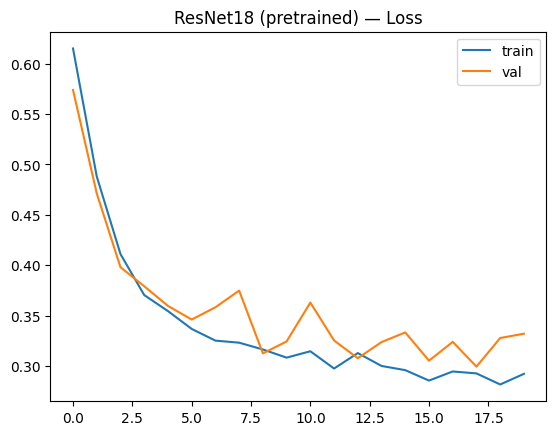

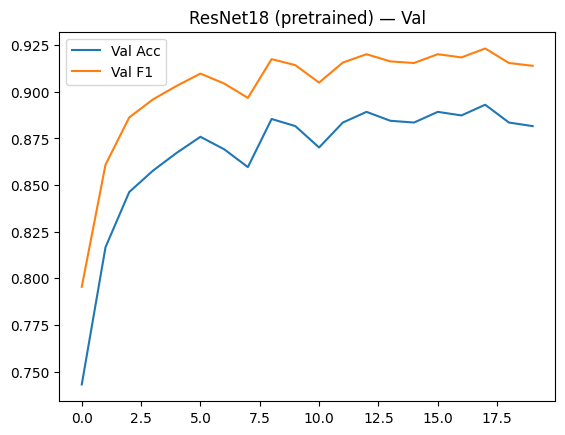

[ResNet18-pretrained @0.5] {'acc': 0.8862, 'precision': 0.9018, 'recall': 0.9179, 'f1': 0.9098, 'auroc': 0.9493, 'thr': 0.5}
[ResNet18-pretrained @Rec] {'acc': 0.8654, 'precision': 0.8297, 'recall': 0.9872, 'f1': 0.9016, 'auroc': 0.9493, 'thr': 0.1695}


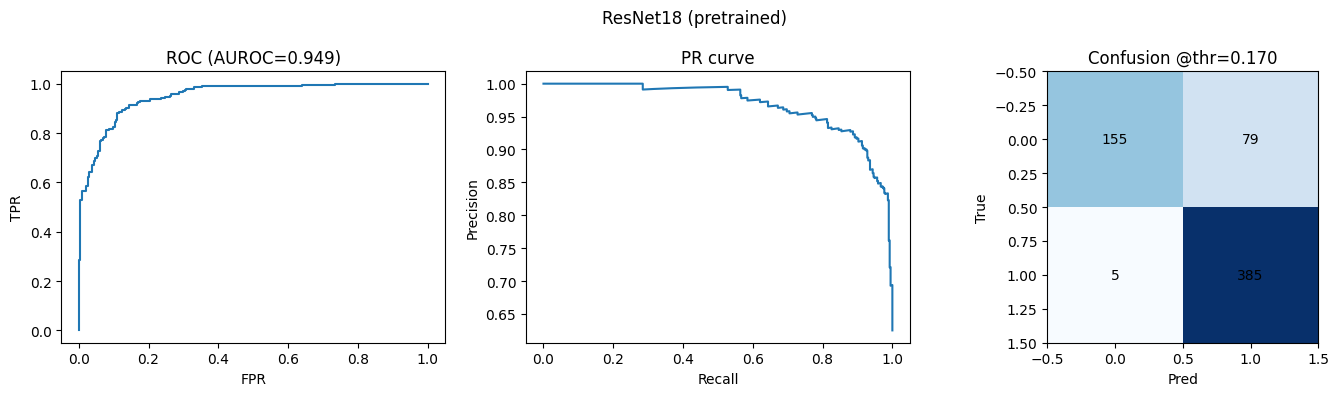

{'summary@0.5': {'acc': 0.8862179487179487,
  'precision': 0.9017632241813602,
  'recall': 0.9179487179487179,
  'f1': 0.9097839898348158,
  'auroc': 0.9492987069910147,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8653846153846154,
  'precision': 0.8297413793103449,
  'recall': 0.9871794871794872,
  'f1': 0.9016393442622951,
  'auroc': 0.9492987069910147,
  'thr': 0.1695},
 'threshold': 0.1695,
 'time_sec': 1755.7310121059418,
 'params': 11177538}

In [3]:
# --- Cell 3: ResNet18 (pretrained, SAM OFF) ---
cfg = resnet_pre_cfg

rn = build_resnet18(in_chans=3, num_classes=2, pretrained=True, conv_stem=False)
t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=cfg.epochs, base_lr=cfg.base_lr, weight_decay=cfg.weight_decay,
    label_smoothing=cfg.label_smoothing,
    use_sam=False, sam_rho=0.05,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=cfg.llrd, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-pretrained"
)
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (pretrained) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (pretrained) — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-pretrained @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-pretrained @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (pretrained)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (pretrained)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-B/16-pretrained] epoch 01/20  tr_loss=0.5707  val_loss=0.5573  val_acc=0.7698  val_f1=0.8173  val_auroc=0.9572  (no_improve=0)
[ViT-B/16-pretrained] epoch 02/20  tr_loss=0.4550  val_loss=0.4028  val_acc=0.8520  val_f1=0.8905  val_auroc=0.9596  (no_improve=0)
[ViT-B/16-pretrained] epoch 03/20  tr_loss=0.4171  val_loss=0.3161  val_acc=0.8959  val_f1=0.9260  val_auroc=0.9688  (no_improve=0)
[ViT-B/16-pretrained] epoch 04/20  tr_loss=0.4093  val_loss=0.4905  val_acc=0.8185  val_f1=0.8617  val_auroc=0.9639  (no_improve=1)
[ViT-B/16-pretrained] epoch 05/20  tr_loss=0.3952  val_loss=0.3799  val_acc=0.8691  val_f1=0.9041  val_auroc=0.9728  (no_improve=0)
[ViT-B/16-pretrained] epoch 06/20  tr_loss=0.3568  val_loss=0.4459  val_acc=0.8376  val_f1=0.8782  val_auroc=0.9788  (no_improve=0)
[ViT-B/16-pretrained] epoch 07/20  tr_loss=0.3727  val_loss=0.3490  val_acc=0.8663  val_f1=0.9021  val_auroc=0.9723  (no_improve=1)
[ViT-B/16-pretrained] epoch 08/20  tr_loss=0.3611  val_loss=0.2953  val_acc=

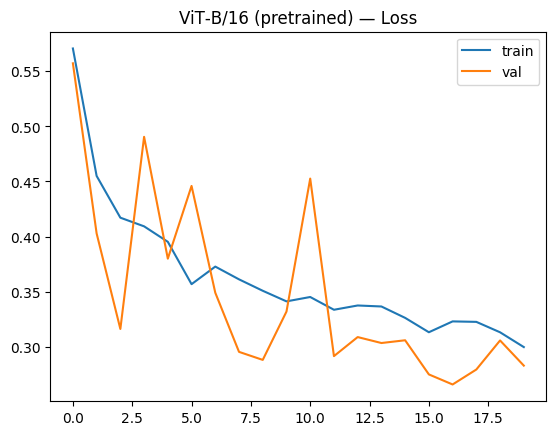

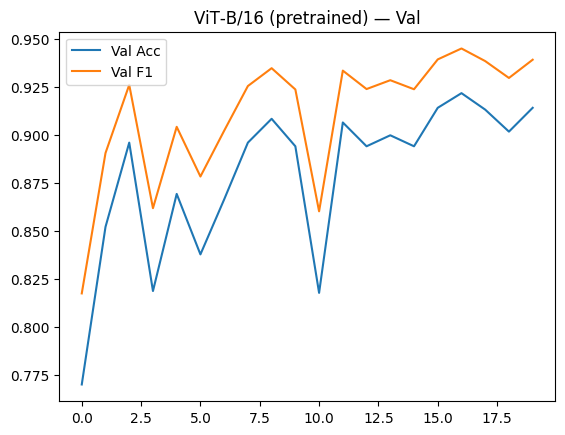

[ViT-B/16-pretrained @0.5] {'acc': 0.8878, 'precision': 0.8828, 'recall': 0.9462, 'f1': 0.9134, 'auroc': 0.9441, 'thr': 0.5}
[ViT-B/16-pretrained @Rec] {'acc': 0.8462, 'precision': 0.8075, 'recall': 0.9897, 'f1': 0.8894, 'auroc': 0.9441, 'thr': 0.1755}


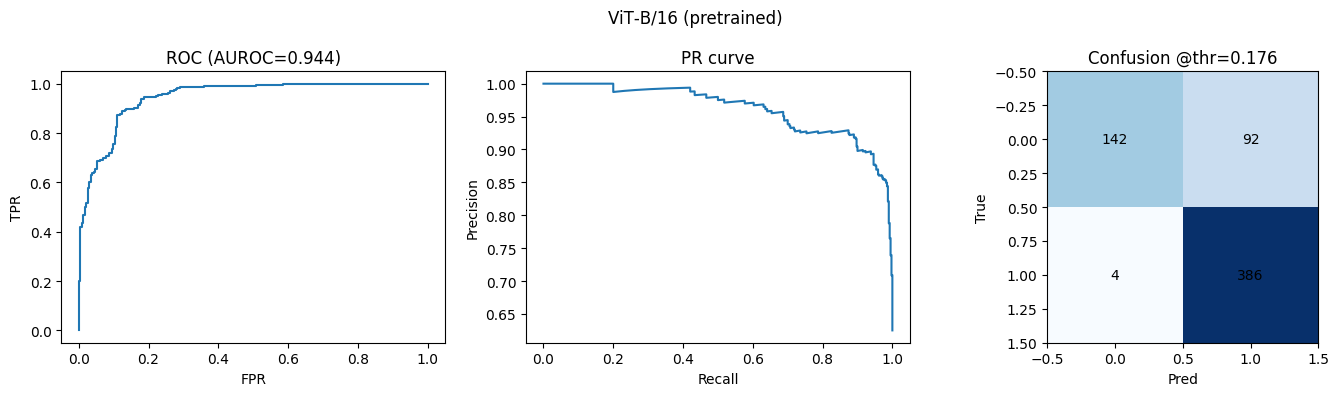

In [4]:
# --- Cell 4: ViT-B/16 (pretrained, SAM OFF) ---
cfg = vit_pre_cfg

try:
    vit = build_vit_pretrained(
        num_classes=2, model_name="vit_base_patch16_224",
        pretrained=True, npz_path=cfg.vit_npz_path
    )
except Exception as e:
    print("ViT-B/16 pretrained unavailable (no timm and no .npz). Skipping ViT cell.")
    vit = None

if vit is not None:
    t0 = time.time()
    vit_tr, vit_hist, vit_time = train_model(
        vit, train_loader, val_loader, DEVICE, arch="vit",
        epochs=cfg.epochs, base_lr=cfg.base_lr, weight_decay=cfg.weight_decay,
        label_smoothing=cfg.label_smoothing,
        use_sam=False, sam_rho=0.20,
        use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
        monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
        class_weights=class_weights, llrd=cfg.llrd, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
        tag="ViT-B/16-pretrained"
    )
    vit_time = time.time() - t0

    plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT‑B/16 (pretrained) — Loss")
    plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT‑B/16 (pretrained) — Val")

    va = evaluate(vit_tr, val_loader, DEVICE)
    thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
    te = evaluate(vit_tr, test_loader, DEVICE)
    sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
    sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
    print("[ViT-B/16-pretrained @0.5]", {k: round(v,4) for k,v in sum_05.items()})
    print("[ViT-B/16-pretrained @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
    diag_plots("ViT‑B/16 (pretrained)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
    add_result("ViT‑B/16 (pretrained)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [5]:
# --- Cell 5: collate results ---
import pandas as pd
from src import result_registry as RR

rows=[]
for name, d in RR.items():
    s = d.get("summary@recall", d.get("summary@0.5"))
    if not s: 
        continue
    thr = d.get("threshold", s.get("thr", 0.5))
    rows.append({
        "Model": name,
        "Params (M)": round(d.get("params", 0)/1e6, 2) if d.get("params") else None,
        "Time (min)": round(d.get("time_sec", 0)/60, 2) if d.get("time_sec") else None,
        "Acc": round(s["acc"],4), "Prec": round(s["precision"],4),
        "Recall": round(s["recall"],4), "F1": round(s["f1"],4),
        "AUROC": round(s.get("auroc", float('nan')),4), "Thr": round(thr,3)
    })
df = pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ResNet18 (pretrained),11.18,29.26,0.8654,0.8297,0.9872,0.9016,0.9493,0.170
1,ViT‑B/16 (pretrained),85.80,136.21,0.8462,0.8075,0.9897,0.8894,0.9441,0.176


                Model  Params (M)  Time (min)    Acc   Prec  Recall     F1  AUROC   Thr
ResNet18 (pretrained)       11.18       29.26 0.8654 0.8297  0.9872 0.9016 0.9493 0.170
ViT‑B/16 (pretrained)       85.80      136.21 0.8462 0.8075  0.9897 0.8894 0.9441 0.176
